<a href="https://colab.research.google.com/github/pranshugarg123/MedPredict/blob/main/medpredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


Data Collection and Analysis

In [ ]:
insurance_dataset=pd.read_csv('/content/insurance.csv')


In [ ]:
#first 5 rows of data frame
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#number of rows and columns
insurance_dataset.shape

(1338, 7)

In [ ]:
#getting more information about dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**Categorical Features**

- Sex  
- Smoker  
- Region


In [ ]:
#checking for missing values
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Data Analysis

In [ ]:
#statistical measures of dataset
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Figure size 600x600 with 0 Axes>

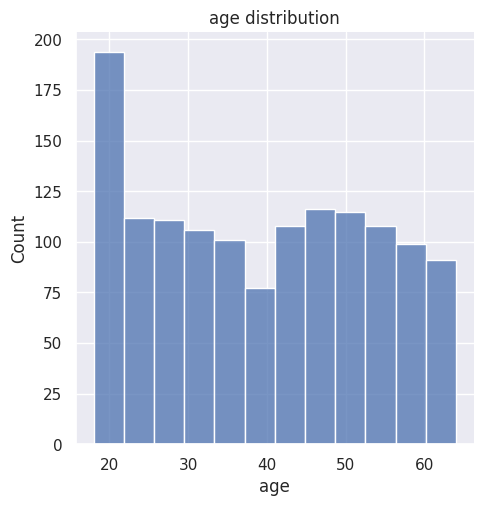

In [ ]:
#distribution of age value
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['age'])
plt.title('age distribution')
plt.show()

In [ ]:
insurance_dataset['sex'].value_counts()

,count
sex,
male,676
female,662


<Figure size 600x600 with 0 Axes>

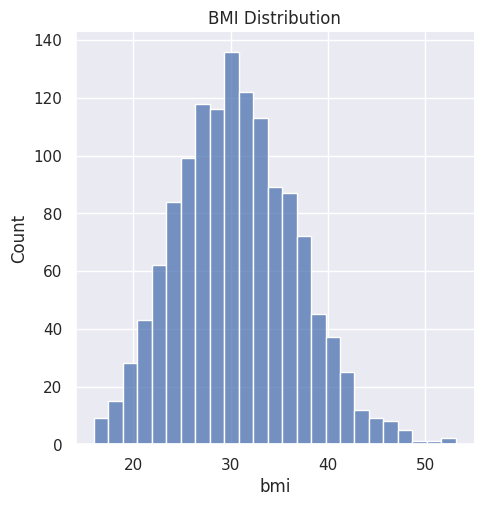

In [ ]:
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['bmi'])
plt.title('BMI Distribution')
plt.show()
#normal bmi range is 18.5 to 24.9

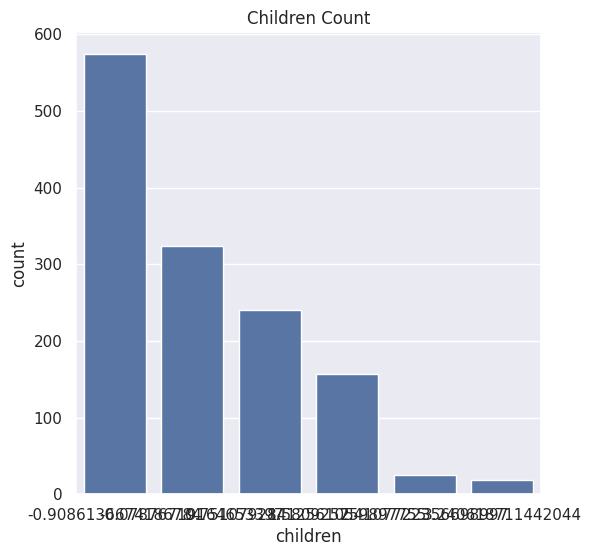

In [ ]:
#children column
plt.figure(figsize=(6,6))
sns.countplot(x='children',data=insurance_dataset)
plt.title('Children Count')
plt.show()


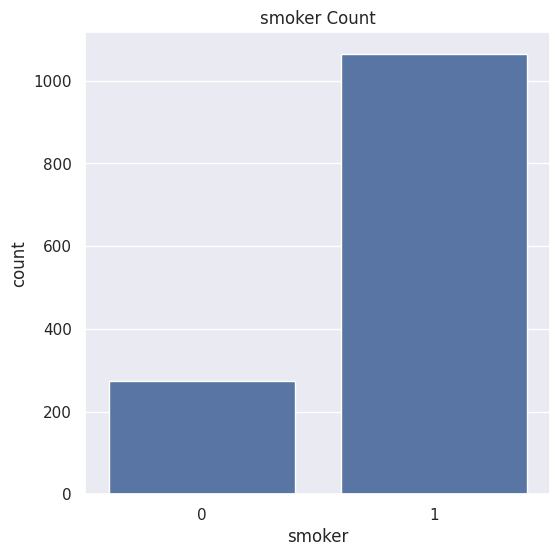

In [ ]:
#children column
plt.figure(figsize=(6,6))
sns.countplot(x='smoker',data=insurance_dataset)
plt.title('smoker Count')
plt.show()


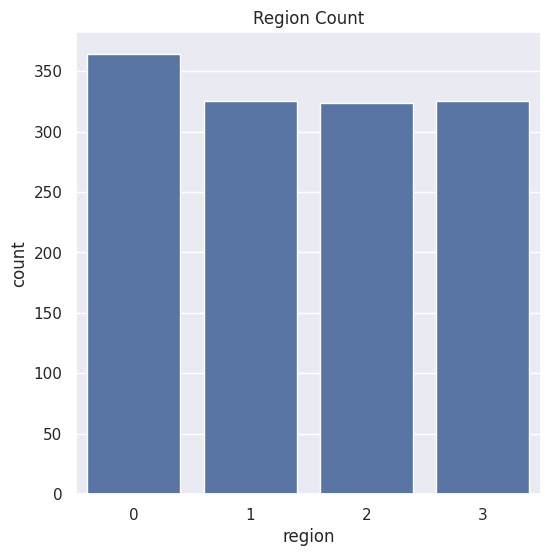

In [ ]:
#children column
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=insurance_dataset)
plt.title('Region Count')
plt.show()


<Figure size 600x600 with 0 Axes>

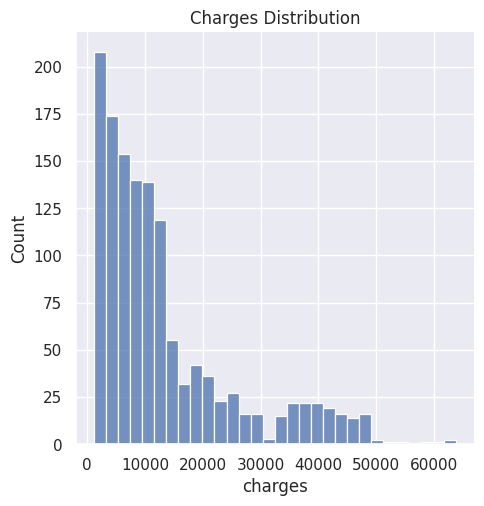

In [ ]:
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['charges'])
plt.title('Charges Distribution')
plt.show()


Data Pre-Processing

In [ ]:
#encoding sex column
insurance_dataset.replace({'sex':{'male':0,'female':1}},inplace=True)
#encloding smoker column
insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace=True)
#encoding region column
insurance_dataset.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}}, inplace=True)
insurance_dataset.head()


/tmp/ipython-input-220536543.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{'male':0,'female':1}},inplace=True)
/tmp/ipython-input-220536543.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace=True)
/tmp/ipython-input-220536543.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the 

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to scale
num_features = ['age', 'bmi', 'children']

# Apply StandardScaler
scaler = StandardScaler()
insurance_dataset[num_features] = scaler.fit_transform(insurance_dataset[num_features])


In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = insurance_dataset.drop('charges', axis=1)
y = insurance_dataset['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, preds, model_name):
    print(f"--- {model_name} ---")
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R2 Score:", r2_score(y_test, preds))
    print()

# Evaluate both
evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, rf_preds, "Random Forest")


--- Linear Regression ---
MAE: 4190.220190137916
R2 Score: 0.783021587162344

--- Random Forest ---
MAE: 2508.0941640965843
R2 Score: 0.8680594097029373



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best model from grid search
best_rf = grid_search.best_estimator_

# Predict and evaluate
best_rf_preds = best_rf.predict(X_test)

print("Tuned Random Forest:")
print("MAE:", mean_absolute_error(y_test, best_rf_preds))
print("R2 Score:", r2_score(y_test, best_rf_preds))
print("Best Parameters:", grid_search.best_params_)


Tuned Random Forest:
MAE: 2450.510322025708
R2 Score: 0.8733254235545564
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

evaluate(y_test, xgb_preds, "XGBoost")


--- XGBoost ---
MAE: 2719.986046608826
R2 Score: 0.8445815927136182



In [ ]:
results = {
    "Linear Regression": [mean_absolute_error(y_test, lr_preds), r2_score(y_test, lr_preds)],
    "Random Forest": [mean_absolute_error(y_test, rf_preds), r2_score(y_test, rf_preds)],
    "Tuned RF": [mean_absolute_error(y_test, best_rf_preds), r2_score(y_test, best_rf_preds)],
    "XGBoost": [mean_absolute_error(y_test, xgb_preds), r2_score(y_test, xgb_preds)]
}

results_df = pd.DataFrame(results, index=["MAE", "R2 Score"]).T
results_df


,MAE,R2 Score
Linear Regression,4190.220190,0.783022
Random Forest,2508.094164,0.868059
Tuned RF,2450.510322,0.873325
XGBoost,2719.986047,0.844582


In [ ]:
!pip install shap


In [ ]:
import shap

# Use TreeExplainer for tree-based models like Random Forest
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)


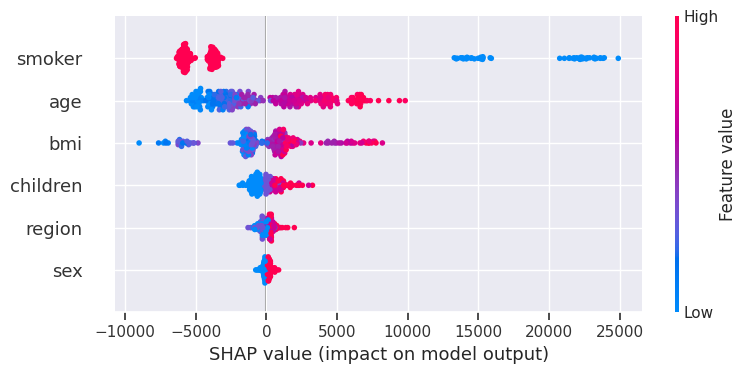

In [ ]:
shap.summary_plot(shap_values, X_test)


### SHAP Summary Plot Interpretation

The SHAP summary plot provides a visual explanation of how each feature influences the model's predictions using SHAP (SHapley Additive exPlanations) values.

**Axes:**
- **Y-axis:** Lists the features used in the model (e.g., `smoker`, `age`, `bmi`, etc.).
- **X-axis:** Represents the SHAP value for each feature, indicating how much that feature contributes to increasing or decreasing the prediction.
  - SHAP value > 0: Feature increases the predicted output.
  - SHAP value < 0: Feature decreases the predicted output.

**Colors:**
- **Red:** High feature value.
- **Blue:** Low feature value.
- **Purple:** Medium feature value.

**Feature-wise Interpretation:**
- **Smoker:** This feature has the most significant impact. High values (i.e., being a smoker) increase the predicted value sharply. Non-smokers (blue dots) decrease the prediction.
- **Age:** Higher age (red) increases predictions, while lower age (blue) decreases them.
- **BMI:** High BMI contributes positively to the prediction, while low BMI decreases it.
- **Children, Region, Sex:** These features have relatively smaller contributions to the model prediction, with SHAP values clustering near zero.

**Conclusion:**
The plot reveals which features are most influential in the model and how their values

In [ ]:
import pickle

# Save the tuned Random Forest model
with open("rf_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

# Save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
